# 10. Multiclass Classification

Multiclass classification is a supervised learning problem where the target variable contains more than two possible classes.

For example, suppose we want to classify animals:

- Class 0 → Cat
- Class 1 → Dog
- Class 2 → Horse

The machine learning model receives input features and predicts one class.

Mathematically:

$$
X \rightarrow Y
$$

where:

$$
Y \in \{0,1,2,\dots,K-1\}
$$

and $K$ is the number of classes.

For example, with three classes:

$$
Y \in \{0,1,2\}
$$

### Examples of multiclass classification

- Iris flower classification
- Handwritten digit recognition
- Animal classification
- News article classification
- Customer segmentation
- Disease type classification

In this notebook, we will learn how different machine learning algorithms solve multiclass classification problems.

In [2]:
# Import the main libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. What is Multiclass Classification?

Classification is a supervised learning task where a model learns to predict a categorical target.

There are three important classification settings:

### Binary Classification

There are exactly two classes.

$$
Y \in \{0,1\}
$$

Example:

- Spam
- Not Spam

---

### Multiclass Classification

There are more than two classes.

$$
Y \in \{0,1,2,\dots,K-1\}
$$

Each observation belongs to exactly one class.

Example:

- Setosa
- Versicolor
- Virginica

---

### Multilabel Classification

An observation can belong to multiple classes at the same time.

For example, an image may contain:

- Dog
- Car
- Tree

Therefore, multiclass and multilabel classification are different problems.

This notebook focuses on multiclass classification.

In [3]:
# Simple example of class labels

classes = np.array([
    "Cat",
    "Dog",
    "Horse"
])

print("Classes:")
for i, class_name in enumerate(classes):
    print(f"{i} → {class_name}")

Classes:
0 → Cat
1 → Dog
2 → Horse


## 2. Binary vs Multiclass Classification

### Binary Classification

A binary classifier chooses between two classes.

For example:

$$
Y \in \{0,1\}
$$

The model may estimate:

$$
P(Y=1|X)
$$

and then choose a class based on the predicted probability.

---

### Multiclass Classification

A multiclass classifier chooses between $K$ classes.

For three classes:

$$
Y \in \{0,1,2\}
$$

The model can produce:

$$
P(Y=0|X)
$$

$$
P(Y=1|X)
$$

$$
P(Y=2|X)
$$

The probabilities must satisfy:

$$
P(Y=0|X)+P(Y=1|X)+P(Y=2|X)=1
$$

The predicted class is normally the class with the highest probability.

In [4]:
# Example probability distribution for a 3-class problem

probabilities = np.array([
    0.10,
    0.70,
    0.20
])

print("Class 0 probability:", probabilities[0])
print("Class 1 probability:", probabilities[1])
print("Class 2 probability:", probabilities[2])

print("\nSum:", probabilities.sum())

predicted_class = np.argmax(probabilities)

print("Predicted class:", predicted_class)

Class 0 probability: 0.1
Class 1 probability: 0.7
Class 2 probability: 0.2

Sum: 1.0
Predicted class: 1


## 3. Types of Multiclass Classification

There are several ways to solve multiclass classification.

The most important approaches are:

### 1. One-vs-Rest

Also called:

- One-vs-All
- OvR
- OVA

One classifier is created for each class.

---

### 2. One-vs-One

Also called:

- OvO

A binary classifier is created for every pair of classes.

---

### 3. Multinomial Classification

The model directly handles all classes together.

Multinomial Logistic Regression is an important example.

It uses the **Softmax function** to calculate class probabilities.

## 4. One-vs-Rest (OvR)

Suppose there are three classes:

$$
A,\ B,\ C
$$

One-vs-Rest creates three binary classifiers.

### Classifier 1

$$
A \quad vs \quad (B,C)
$$

### Classifier 2

$$
B \quad vs \quad (A,C)
$$

### Classifier 3

$$
C \quad vs \quad (A,B)
$$

For a new observation, every classifier produces a score.

The classifier with the highest score determines the final class.

### Number of classifiers

For $K$ classes:

$$
\boxed{K}
$$

binary classifiers are required.

Therefore, OvR is often computationally attractive when there are many classes.

In [5]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

# Example training data

X_example = np.array([
    [1, 1],
    [1, 2],
    [2, 1],
    [5, 5],
    [5, 6],
    [6, 5],
    [9, 1],
    [9, 2],
    [10, 1]
])

y_example = np.array([
    0, 0, 0,
    1, 1, 1,
    2, 2, 2
])

# Base binary classifier
base_model = LogisticRegression()

# One-vs-Rest classifier
ovr_model = OneVsRestClassifier(base_model)

ovr_model.fit(X_example, y_example)

print("Number of classes:", len(ovr_model.classes_))
print("Number of binary classifiers:", len(ovr_model.estimators_))

Number of classes: 3
Number of binary classifiers: 3


In [6]:
# Make predictions using One-vs-Rest

X_new = np.array([
    [1.5, 1.5],
    [5.5, 5.5],
    [9.5, 1.5]
])

ovr_predictions = ovr_model.predict(X_new)

print("Predictions:", ovr_predictions)

Predictions: [0 1 2]


## 5. Understanding the OvR Classifiers

For three classes, the OvR model creates:

$$
3
$$

binary classifiers.

Each classifier answers a different question:

| Classifier | Question |
|---|---|
| Classifier 1 | Is this Class 0? |
| Classifier 2 | Is this Class 1? |
| Classifier 3 | Is this Class 2? |

The final prediction is selected from the classifier scores.

Therefore, OvR transforms a multiclass problem into multiple binary classification problems.

In [7]:
# Inspect the individual OvR classifiers

for i, estimator in enumerate(ovr_model.estimators_):
    print(f"Classifier {i}:")
    print("Coefficients:", estimator.coef_)
    print("Intercept:", estimator.intercept_)
    print()

Classifier 0:
Coefficients: [[-0.88130678 -0.56943972]]
Intercept: [4.69553815]

Classifier 1:
Coefficients: [[0.01361154 1.26043204]]
Intercept: [-4.67586614]

Classifier 2:
Coefficients: [[ 0.89429454 -0.55786294]]
Intercept: [-4.83617171]



## 6. One-vs-One (OvO)

One-vs-One creates one binary classifier for every pair of classes.

Suppose there are three classes:

$$
A,\ B,\ C
$$

The classifiers are:

$$
A \text{ vs } B
$$

$$
A \text{ vs } C
$$

$$
B \text{ vs } C
$$

Each classifier produces a vote.

The class with the most votes becomes the final prediction.

### Number of classifiers

For $K$ classes:

$$
\boxed{
\frac{K(K-1)}{2}
}
$$

For three classes:

$$
\frac{3(3-1)}{2}=3
$$

For four classes:

$$
\frac{4(4-1)}{2}=6
$$

For ten classes:

$$
\frac{10(10-1)}{2}=45
$$

In [8]:
from sklearn.multiclass import OneVsOneClassifier

ovo_model = OneVsOneClassifier(
    LogisticRegression()
)

ovo_model.fit(
    X_example,
    y_example
)

print("Number of classes:", len(ovo_model.classes_))
print("Number of binary classifiers:", len(ovo_model.estimators_))

Number of classes: 3
Number of binary classifiers: 3


In [9]:
# Make predictions using OvO

ovo_predictions = ovo_model.predict(X_new)

print("Predictions:", ovo_predictions)

Predictions: [0 1 2]


In [10]:
# Verify the mathematical formula

def number_of_ovo_classifiers(k):
    return k * (k - 1) // 2


for k in [3, 4, 5, 10]:
    print(
        f"{k} classes → "
        f"{number_of_ovo_classifiers(k)} classifiers"
    )

3 classes → 3 classifiers
4 classes → 6 classifiers
5 classes → 10 classifiers
10 classes → 45 classifiers


## 7. One-vs-Rest vs One-vs-One

The two strategies can be compared as follows:

| Method | Number of Classifiers | Strategy |
|---|---:|---|
| One-vs-Rest | $K$ | One class vs all other classes |
| One-vs-One | $\frac{K(K-1)}{2}$ | Every pair of classes |

### OvR

Advantages:

- Requires fewer classifiers
- Efficient when there are many classes
- Simple concept

### OvO

Advantages:

- Each classifier only needs to distinguish two classes
- Can work well with algorithms such as SVM

The best strategy depends on the algorithm and dataset.

## 8. Multinomial Logistic Regression

Logistic Regression can be extended to multiple classes.

Instead of producing only one probability, the model produces one probability for every class.

For $K$ classes:

$$
P(Y=k|X)
=
\frac{e^{z_k}}
{\sum_{j=1}^{K}e^{z_j}}
$$

where:

$$
z_k=w_k^TX+b_k
$$

Here:

- $w_k$ = weight vector for class $k$
- $b_k$ = bias for class $k$
- $z_k$ = score for class $k$

The Softmax function converts these scores into probabilities.

The class with the highest probability becomes the prediction.

## 9. Softmax Function

The Softmax function converts multiple model scores into probabilities.

For three classes:

$$
z_0,z_1,z_2
$$

the probabilities are:

$$
P(Y=0|X)
=
\frac{e^{z_0}}
{e^{z_0}+e^{z_1}+e^{z_2}}
$$

$$
P(Y=1|X)
=
\frac{e^{z_1}}
{e^{z_0}+e^{z_1}+e^{z_2}}
$$

$$
P(Y=2|X)
=
\frac{e^{z_2}}
{e^{z_0}+e^{z_1}+e^{z_2}}
$$

The probabilities satisfy:

$$
\sum_{k=0}^{K-1}P(Y=k|X)=1
$$

In [11]:
def softmax(z):
    z = np.array(z)

    # Numerical stability
    z = z - np.max(z)

    exp_values = np.exp(z)

    probabilities = (
        exp_values / exp_values.sum()
    )

    return probabilities


scores = np.array([
    2.0,
    1.0,
    0.1
])

probabilities = softmax(scores)

print("Scores:")
print(scores)

print("\nSoftmax probabilities:")
print(probabilities)

print("\nSum:")
print(probabilities.sum())

print("\nPredicted class:")
print(np.argmax(probabilities))

Scores:
[2.  1.  0.1]

Softmax probabilities:
[0.65900114 0.24243297 0.09856589]

Sum:
1.0

Predicted class:
0


## 10. Understanding Softmax

Suppose the model produces:

$$
z=[2.0,1.0,0.1]
$$

Softmax transforms these scores into probabilities.

The largest score receives the largest probability.

However, the other classes also receive probabilities.

For example:

$$
[0.659,\ 0.242,\ 0.099]
$$

The probabilities sum to:

$$
1
$$

The predicted class is:

$$
\arg\max_k P(Y=k|X)
$$

Therefore:

$$
\boxed{\text{Class 0}}
$$

is predicted.

Softmax is therefore useful when we want a probability distribution across multiple mutually exclusive classes.

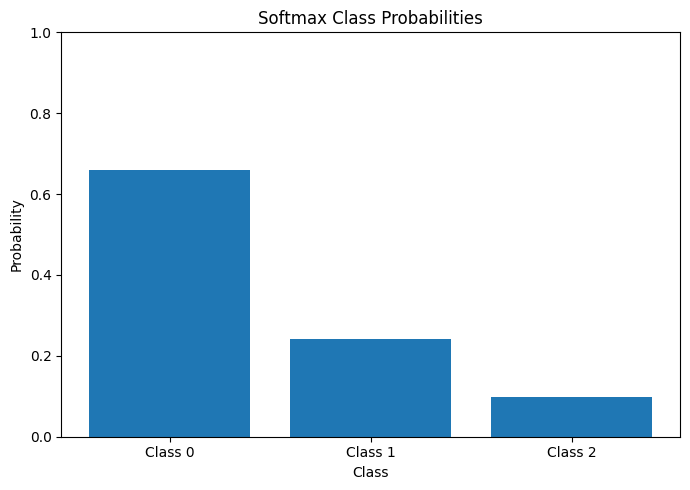

In [12]:
# Visualize the Softmax probabilities

class_labels = ["Class 0", "Class 1", "Class 2"]

plt.figure(figsize=(7, 5))

plt.bar(
    class_labels,
    probabilities
)

plt.xlabel("Class")
plt.ylabel("Probability")
plt.title("Softmax Class Probabilities")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## 11. Multiclass Cross-Entropy Loss

Cross-Entropy Loss is commonly used for multiclass classification.

For one observation:

$$
L
=
-\sum_{k=1}^{K}
y_k\log(\hat{p}_k)
$$

where:

- $y_k$ = true value for class $k$
- $\hat{p}_k$ = predicted probability for class $k$
- $K$ = number of classes

Suppose the true class is Class 2:

$$
y=[0,0,1]
$$

and the model predicts:

$$
\hat{p}=[0.1,0.2,0.7]
$$

Then:

$$
L
=
-\left[
0\log(0.1)
+
0\log(0.2)
+
1\log(0.7)
\right]
$$

Therefore:

$$
L=-\log(0.7)
$$

A higher probability assigned to the correct class produces a smaller loss.

In [13]:
def multiclass_cross_entropy(y_true, y_pred):
    y_pred = np.clip(
        y_pred,
        1e-15,
        1 - 1e-15
    )

    loss = -np.sum(
        y_true * np.log(y_pred)
    )

    return loss


y_true = np.array([0, 0, 1])

y_pred = np.array([
    0.1,
    0.2,
    0.7
])

loss = multiclass_cross_entropy(
    y_true,
    y_pred
)

print("Cross-Entropy Loss:", loss)

Cross-Entropy Loss: 0.35667494393873245


In [14]:
# Compare good and bad predictions

good_prediction = np.array([
    0.05,
    0.05,
    0.90
])

bad_prediction = np.array([
    0.90,
    0.05,
    0.05
])

good_loss = multiclass_cross_entropy(
    y_true,
    good_prediction
)

bad_loss = multiclass_cross_entropy(
    y_true,
    bad_prediction
)

print("Good prediction loss:", good_loss)
print("Bad prediction loss:", bad_loss)

Good prediction loss: 0.10536051565782628
Bad prediction loss: 2.995732273553991


## 12. Why Cross-Entropy Penalizes Confident Wrong Predictions

Suppose the true class is Class 2.

If the model predicts:

$$
P(Y=2)=0.90
$$

the loss is small:

$$
L=-\log(0.90)
$$

But if the model predicts:

$$
P(Y=2)=0.01
$$

the loss becomes:

$$
L=-\log(0.01)
$$

which is much larger.

Therefore, Cross-Entropy strongly penalizes predictions that assign very low probability to the correct class.

This encourages the model not only to predict the correct class but also to assign it a high probability.

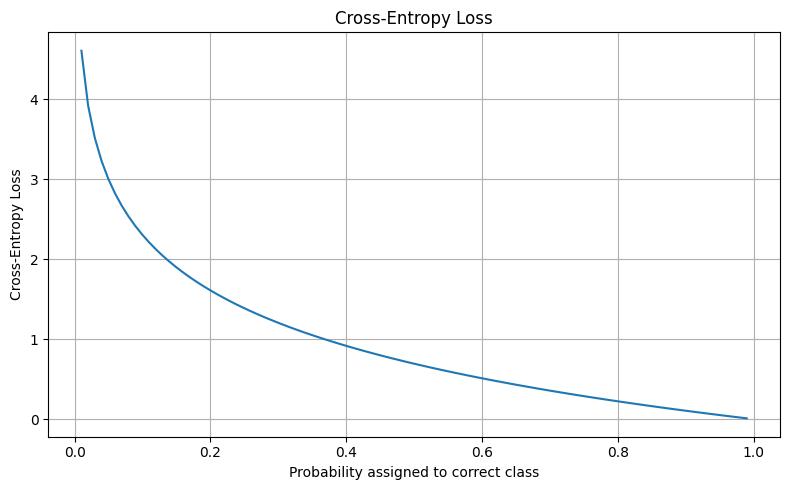

In [15]:
# Visualize how Cross-Entropy changes
# as the probability of the correct class changes.

correct_probabilities = np.linspace(
    0.01,
    0.99,
    100
)

losses = -np.log(correct_probabilities)

plt.figure(figsize=(8, 5))

plt.plot(
    correct_probabilities,
    losses
)

plt.xlabel("Probability assigned to correct class")
plt.ylabel("Cross-Entropy Loss")
plt.title("Cross-Entropy Loss")

plt.grid(True)
plt.tight_layout()
plt.show()

## 13. Loading a Real Multiclass Dataset

We will use the Iris dataset.

The Iris dataset contains:

### Features

1. Sepal length
2. Sepal width
3. Petal length
4. Petal width

### Target classes

1. Setosa
2. Versicolor
3. Virginica

Therefore:

$$
K=3
$$

and:

$$
Y\in\{0,1,2\}
$$

In [16]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

print("Feature names:")
print(feature_names)

print("\nTarget names:")
print(target_names)

print("\nNumber of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", len(target_names))

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']

Number of samples: 150
Number of features: 4
Number of classes: 3


In [17]:
# Create a DataFrame

iris_df = pd.DataFrame(
    X,
    columns=feature_names
)

iris_df["target"] = y

iris_df["species"] = iris_df["target"].map(
    {
        0: "setosa",
        1: "versicolor",
        2: "virginica"
    }
)

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 14. Exploring the Class Distribution

Before training a classifier, we should understand how many observations belong to each class.

A balanced dataset has approximately similar numbers of observations in each class.

Class imbalance can affect evaluation metrics and model performance.

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


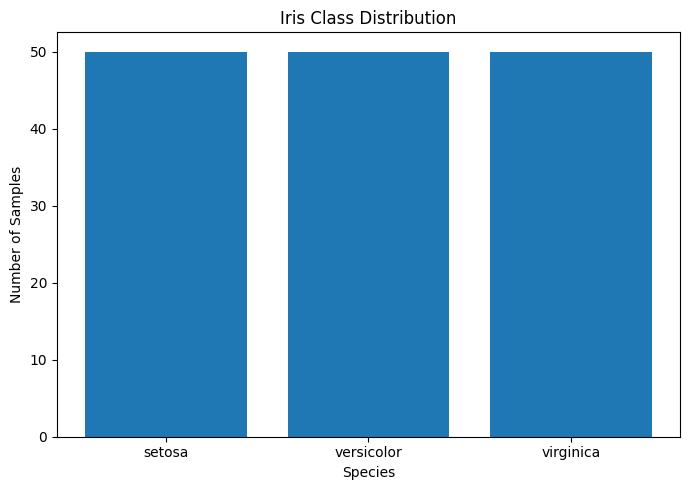

In [18]:
class_counts = iris_df["species"].value_counts()

print(class_counts)

plt.figure(figsize=(7, 5))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.xlabel("Species")
plt.ylabel("Number of Samples")
plt.title("Iris Class Distribution")

plt.tight_layout()
plt.show()

## 15. Train-Test Split

We divide the dataset into training and testing sets.

The training set is used to learn the model.

The testing set is used to evaluate the model on unseen observations.

We will use:

$$
80\% \rightarrow Training
$$

$$
20\% \rightarrow Testing
$$

We use `stratify=y` so that the class proportions are approximately preserved in both datasets.

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


## 16. Feature Scaling

Some algorithms are sensitive to feature scale.

Important examples include:

- KNN
- SVM
- Logistic Regression

We standardize features using:

$$
z=
\frac{x-\mu}{\sigma}
$$

where:

- $x$ = original value
- $\mu$ = training mean
- $\sigma$ = training standard deviation

The transformation produces features with approximately:

$$
\mu=0
$$

and:

$$
\sigma=1
$$

We fit the scaler only on the training data and then use the same transformation on the test data.

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature scaling completed.")

Feature scaling completed.


## 17. Multinomial Logistic Regression

We will now train Logistic Regression on the Iris dataset.

For multiclass classification, Logistic Regression can estimate a probability for each class.

The Softmax function is used to transform the class scores into probabilities.

The predicted class is the class with the highest probability.

In [21]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [22]:
# Predictions

y_pred_logistic = logistic_model.predict(
    X_test_scaled
)

print("Predictions:")
print(y_pred_logistic)

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 1 2 2 1 0 2 0]


In [23]:
from sklearn.metrics import accuracy_score

accuracy_logistic = accuracy_score(
    y_test,
    y_pred_logistic
)

print(
    "Logistic Regression Accuracy:",
    accuracy_logistic
)

Logistic Regression Accuracy: 0.9333333333333333


## 18. Class Probabilities

A multiclass Logistic Regression model can provide the probability of every class.

For example:

$$
[0.02,\ 0.95,\ 0.03]
$$

means:

- Class 0 → 2%
- Class 1 → 95%
- Class 2 → 3%

Since Class 1 has the highest probability:

$$
\hat{y}=1
$$

In [24]:
probabilities = logistic_model.predict_proba(
    X_test_scaled
)

print("First five probability predictions:\n")

print(probabilities[:5])

print("\nProbability sums:")

print(probabilities[:5].sum(axis=1))

First five probability predictions:

[[9.78818005e-01 2.11816311e-02 3.63821812e-07]
 [3.79836951e-03 3.69220168e-01 6.26981463e-01]
 [1.48799040e-01 8.42474895e-01 8.72606441e-03]
 [9.54449962e-02 8.94618634e-01 9.93636953e-03]
 [9.88493051e-01 1.15067767e-02 1.72549650e-07]]

Probability sums:
[1. 1. 1. 1. 1.]


## 19. K-Nearest Neighbours for Multiclass Classification

KNN can naturally perform multiclass classification.

For a new observation:

1. Calculate the distance to training observations.
2. Select the $K$ nearest neighbours.
3. Examine their class labels.
4. Choose the class with the majority vote.

For example, if:

$$
K=5
$$

and the neighbour classes are:

$$
[A,A,B,A,C]
$$

then:

- A → 3 votes
- B → 1 vote
- C → 1 vote

Therefore:

$$
\boxed{A}
$$

is predicted.

In [25]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    X_train_scaled,
    y_train
)

y_pred_knn = knn_model.predict(
    X_test_scaled
)

accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.9333333333333333


## 20. Decision Tree for Multiclass Classification

Decision Trees can directly handle multiclass classification.

The tree repeatedly divides the feature space into smaller regions.

Common splitting criteria include:

- Gini impurity
- Entropy
- Log Loss

At the final leaf node, the model predicts a class based on the training observations that reach that leaf.

Unlike KNN, Decision Trees do not require feature scaling.

In [26]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

y_pred_tree = tree_model.predict(
    X_test
)

accuracy_tree = accuracy_score(
    y_test,
    y_pred_tree
)

print("Decision Tree Accuracy:", accuracy_tree)

Decision Tree Accuracy: 0.9333333333333333


## 21. Support Vector Machine for Multiclass Classification

SVM is fundamentally a binary classification algorithm.

For multiclass problems, SVM can use strategies such as One-vs-One.

Scikit-learn's `SVC` handles multiclass classification internally.

We will use an RBF kernel.

The RBF kernel allows the model to learn nonlinear decision boundaries.

In [27]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(
    X_train_scaled,
    y_train
)

y_pred_svm = svm_model.predict(
    X_test_scaled
)

accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.9666666666666667


## 22. Comparing the Four Models

We have now trained:

1. Logistic Regression
2. KNN
3. Decision Tree
4. SVM

We will compare their test accuracy.

Accuracy is:

$$
Accuracy=
\frac{\text{Correct Predictions}}
{\text{Total Predictions}}
$$

A higher accuracy means that more test observations were classified correctly.

However, accuracy should not be the only metric considered, especially when classes are imbalanced.

In [28]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_knn,
        accuracy_tree,
        accuracy_svm
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,SVM,0.966667
0,Logistic Regression,0.933333
1,KNN,0.933333
2,Decision Tree,0.933333


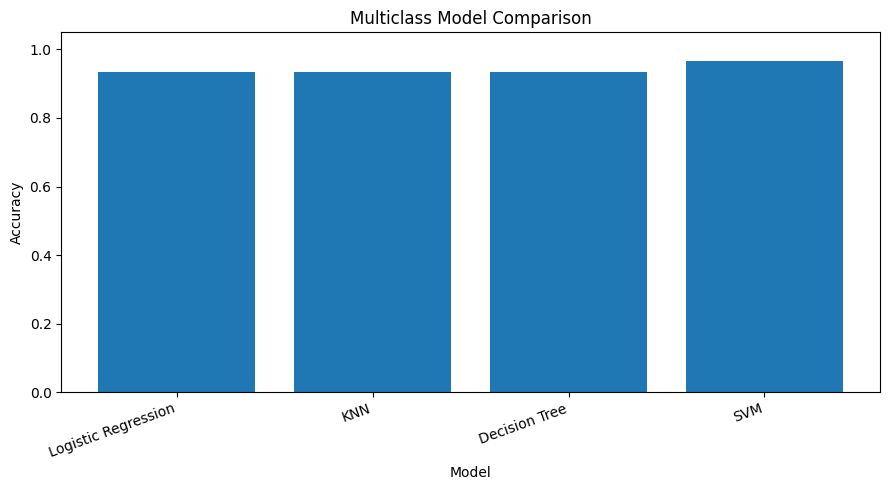

In [29]:
plt.figure(figsize=(9, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Multiclass Model Comparison")

plt.ylim(0, 1.05)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

## 23. Multiclass Evaluation Metrics

Accuracy is not always sufficient.

We can also use:

- Precision
- Recall
- F1-score

For multiclass classification, these metrics can be calculated using different averaging strategies.

### Macro Average

Calculate the metric independently for each class and then take the average.

$$
Metric_{macro}
=
\frac{1}{K}
\sum_{k=1}^{K}Metric_k
$$

Every class receives equal importance.

### Weighted Average

The metric for each class is weighted according to the number of observations in that class.

This is useful when class sizes are unequal.

### Micro Average

The contributions from all classes are aggregated before calculating the metric.

It focuses on overall prediction performance.

In [30]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision_macro = precision_score(
    y_test,
    y_pred_logistic,
    average="macro"
)

recall_macro = recall_score(
    y_test,
    y_pred_logistic,
    average="macro"
)

f1_macro = f1_score(
    y_test,
    y_pred_logistic,
    average="macro"
)

print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1-score:", f1_macro)

Macro Precision: 0.9333333333333332
Macro Recall: 0.9333333333333332
Macro F1-score: 0.9333333333333332


In [31]:
# Compare macro and weighted F1-score

f1_macro = f1_score(
    y_test,
    y_pred_logistic,
    average="macro"
)

f1_weighted = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

print("Macro F1-score:", f1_macro)
print("Weighted F1-score:", f1_weighted)

Macro F1-score: 0.9333333333333332
Weighted F1-score: 0.9333333333333333


## 24. Classification Report

The classification report provides:

- Precision
- Recall
- F1-score
- Support

for every class.

### Support

Support is the number of actual observations belonging to each class in the evaluation dataset.

This makes the classification report useful for identifying whether a model performs well on every class or only on the majority class.

In [32]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 25. Confusion Matrix

A confusion matrix shows the relationship between actual classes and predicted classes.

For three classes:

$$
\begin{bmatrix}
C_{00} & C_{01} & C_{02}\\
C_{10} & C_{11} & C_{12}\\
C_{20} & C_{21} & C_{22}
\end{bmatrix}
$$

Rows represent the actual classes.

Columns represent the predicted classes.

The diagonal elements represent correct predictions:

$$
C_{00},C_{11},C_{22}
$$

The off-diagonal elements represent misclassifications.

A confusion matrix therefore tells us **which classes are being confused with each other**.

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


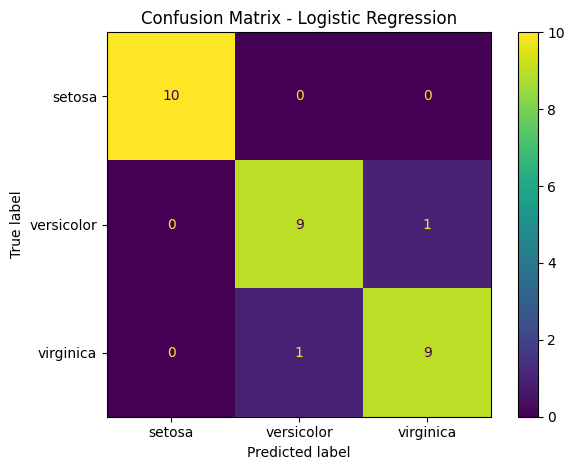

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

disp.plot()

plt.title(
    "Confusion Matrix - Logistic Regression"
)

plt.tight_layout()
plt.show()

## 26. Multiclass Decision Boundaries

A decision boundary separates different classes in feature space.

For example:

$$
Region_1 \rightarrow Class\ 0
$$

$$
Region_2 \rightarrow Class\ 1
$$

$$
Region_3 \rightarrow Class\ 2
$$

The shape of the decision boundary depends on the model.

### Logistic Regression

Usually produces linear decision boundaries.

### KNN

Produces boundaries based on neighbouring observations.

### Decision Tree

Produces axis-aligned regions.

### RBF SVM

Can produce nonlinear and more flexible boundaries.

To visualize decision boundaries easily, we will use two features from the Iris dataset.

In [35]:
# Select two features for visualization

X_visual = iris.data[:, [2, 3]]
y_visual = iris.target

X_train_visual, X_test_visual, y_train_visual, y_test_visual = train_test_split(
    X_visual,
    y_visual,
    test_size=0.20,
    random_state=42,
    stratify=y_visual
)

scaler_visual = StandardScaler()

X_train_visual_scaled = scaler_visual.fit_transform(
    X_train_visual
)

X_test_visual_scaled = scaler_visual.transform(
    X_test_visual
)

print("Visualization dataset prepared.")

Visualization dataset prepared.


In [36]:
# Train Logistic Regression using two features

visual_model = LogisticRegression(
    max_iter=1000
)

visual_model.fit(
    X_train_visual_scaled,
    y_train_visual
)

print("Visualization model trained.")

Visualization model trained.


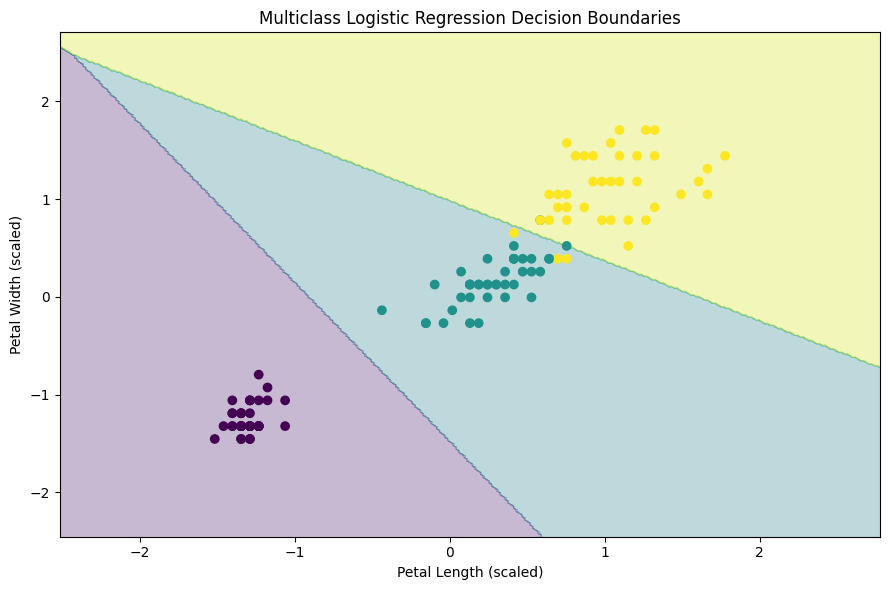

In [37]:
# Create a grid for decision boundary visualization

x_min = X_train_visual_scaled[:, 0].min() - 1
x_max = X_train_visual_scaled[:, 0].max() + 1

y_min = X_train_visual_scaled[:, 1].min() - 1
y_max = X_train_visual_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[
    xx.ravel(),
    yy.ravel()
]

grid_predictions = visual_model.predict(
    grid
)

grid_predictions = grid_predictions.reshape(
    xx.shape
)

plt.figure(figsize=(9, 6))

plt.contourf(
    xx,
    yy,
    grid_predictions,
    alpha=0.3
)

plt.scatter(
    X_train_visual_scaled[:, 0],
    X_train_visual_scaled[:, 1],
    c=y_train_visual
)

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("Multiclass Logistic Regression Decision Boundaries")

plt.tight_layout()
plt.show()

## 27. Practical Multiclass Prediction

We will now use our trained Logistic Regression model to classify a new Iris flower.

Suppose the flower has:

- Sepal length = 5.1
- Sepal width = 3.5
- Petal length = 1.4
- Petal width = 0.2

The model will:

1. Transform the features using the scaler.
2. Calculate class scores.
3. Convert the scores into class probabilities.
4. Select the class with the highest probability.

In [38]:
new_flower = np.array([
    [5.1, 3.5, 1.4, 0.2]
])

new_flower_scaled = scaler.transform(
    new_flower
)

prediction = logistic_model.predict(
    new_flower_scaled
)

probability = logistic_model.predict_proba(
    new_flower_scaled
)

print("Predicted class:", prediction[0])

print(
    "Predicted species:",
    target_names[prediction[0]]
)

print("\nClass probabilities:")

for class_name, prob in zip(
    target_names,
    probability[0]
):
    print(
        f"{class_name}: {prob:.4f}"
    )

Predicted class: 0
Predicted species: setosa

Class probabilities:
setosa: 0.9808
versicolor: 0.0192
virginica: 0.0000


## 28. Common Problems in Multiclass Classification

### 1. Class Imbalance

One class may contain many more observations than another.

For example:

$$
Class\ A=900
$$

$$
Class\ B=80
$$

$$
Class\ C=20
$$

In this situation, accuracy alone may be misleading.

---

### 2. Class Overlap

Different classes may have similar feature distributions.

This makes classification more difficult.

---

### 3. Overfitting

A model may perform very well on training data but poorly on unseen data.

This is especially important for flexible models such as decision trees.

---

### 4. Poor Features

If the input features do not contain useful information for distinguishing the classes, even a powerful model may perform poorly.

---

### 5. Incorrect Evaluation

Using only accuracy can hide poor performance on minority classes.

Precision, recall, F1-score, and the confusion matrix should also be considered.

## 29. Complete Multiclass Classification Workflow

A typical multiclass classification workflow is:

$$
Data
$$

$$
\downarrow
$$

$$
Exploratory\ Data\ Analysis
$$

$$
\downarrow
$$

$$
Data\ Preprocessing
$$

$$
\downarrow
$$

$$
Train-Test\ Split
$$

$$
\downarrow
$$

$$
Feature\ Scaling
$$

$$
\downarrow
$$

$$
Model\ Training
$$

$$
\downarrow
$$

$$
Class\ Probability\ Prediction
$$

$$
\downarrow
$$

$$
Class\ Prediction
$$

$$
\downarrow
$$

$$
Evaluation
$$

Important considerations include:

- Number of classes
- Class distribution
- Feature scaling
- OvR vs OvO
- Softmax probabilities
- Cross-Entropy Loss
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- Decision boundaries

In [39]:
# Final model comparison

final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "SVM"
    ],
    "Accuracy": [
        accuracy_logistic,
        accuracy_knn,
        accuracy_tree,
        accuracy_svm
    ]
})

final_results = final_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

final_results

,Model,Accuracy
0,SVM,0.966667
1,Logistic Regression,0.933333
2,KNN,0.933333
3,Decision Tree,0.933333


# 30. Summary

Multiclass classification predicts one class from more than two possible classes.

The key concepts are:

### One-vs-Rest

Creates one binary classifier for each class.

$$
Number\ of\ classifiers=K
$$

### One-vs-One

Creates one binary classifier for every pair of classes.

$$
Number\ of\ classifiers=
\frac{K(K-1)}{2}
$$

### Softmax

Converts class scores into probabilities.

$$
P(Y=k|X)
=
\frac{e^{z_k}}
{\sum_j e^{z_j}}
$$

### Cross-Entropy Loss

Measures the difference between the true class and predicted probability distribution.

$$
L=
-\sum_k y_k\log(\hat p_k)
$$

### Prediction

The final class is normally:

$$
\hat y=
\arg\max_k P(Y=k|X)
$$

### Evaluation

Important evaluation tools include:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

### Models

We implemented multiclass classification using:

- Logistic Regression
- KNN
- Decision Tree
- SVM

The central idea is:

$$
\boxed{
Input\ Features
\rightarrow
Class\ Scores
\rightarrow
Class\ Probabilities
\rightarrow
Predicted\ Class
}
$$